In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("arjuntejaswi/plant-village")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plant-village' dataset.
Path to dataset files: /kaggle/input/plant-village


In [2]:
#libraries for analysis
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#libraries for preprocessing
import os
from PIL import Image
from sklearn.model_selection import train_test_split
#from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator # for data augmantation


#lib for model
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, BatchNormalization, Dropout, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam, Adamax

#lib for evaluation
from sklearn.metrics import confusion_matrix, classification_report


import warnings
warnings.filterwarnings("ignore")

## PreProcessing

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Define the desired potato classes explicitly
potato_class_names = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/kaggle/input/plant-village/PlantVillage",
    seed=123,
    shuffle=True,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=potato_class_names # Explicitly specify the desired classes
)

Found 2152 files belonging to 3 classes.


In [4]:
len(dataset)

68

In [5]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

## Spliting

In [6]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1 # to ensure that train + val + test= 100%
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [7]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [8]:
print(len(train_ds), len(val_ds), len(test_ds))

54 6 8


## CACHE, SHUFFLE, PREFETCH the dataset

In [9]:
# to make training data more easy and faclitate on GPU
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [10]:
# RESIZING & NORMALIZATION
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(224, 224),
    layers.Rescaling(1./255)
])

## Data Augmantation

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

# Applying Augmantation on training data only
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y))

## Building Model

In [12]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
channels= 3
img_shape= (IMG_SIZE[0],IMG_SIZE[1],channels )
num_class = len(class_names)


# Model Archticture
base_model= keras.applications.EfficientNetB0(
    include_top=True,
    weights="imagenet",
    input_tensor=None,
    input_shape=img_shape,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
    name="efficientnetb0",
)


# MODEL Fine Tuning
model = Sequential([
    base_model,
    BatchNormalization(),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_class, activation='softmax')
])

model.compile(
    optimizer=Adamax(learning_rate=0.0003),
    loss='SparseCategoricalCrossentropy',
    metrics=['accuracy']
)

model.summary()

21834768/21834768 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1000)           │     5,330,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1000)           │         4,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       128,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,463,086 (20.84 MB)

 Trainable params: 5,419,063 (20.67 MB)

 Non-trainable params: 44,023 (171.97 KB)

## Training And Fitting

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 125s 501ms/step - accuracy: 0.8426 - loss: 0.7626 - val_accuracy: 0.8594 - val_loss: 0.9562
Epoch 2/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 291ms/step - accuracy: 0.9485 - loss: 0.2537 - val_accuracy: 0.8646 - val_loss: 0.8209
Epoch 3/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 297ms/step - accuracy: 0.9884 - loss: 0.1010 - val_accuracy: 0.9062 - val_loss: 0.6821
Epoch 4/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 307ms/step - accuracy: 0.9936 - loss: 0.0526 - val_accuracy: 0.9167 - val_loss: 0.5571
Epoch 5/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 295ms/step - accuracy: 0.9954 - loss: 0.0392 - val_accuracy: 0.9167 - val_loss: 0.4418
Epoch 6/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 299ms/step - accuracy: 0.9942 - loss: 0.0323 - val_accuracy: 0.9844 - val_loss: 0.3314
Epoch 7/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 17s 306ms/step - accuracy: 0.9971 - loss: 0.0221 - val_accuracy: 1.0000 - val_loss: 0.2348
Epoch 8/12
54/54 ━━━━━━━━━━━━━━━━━━━━ 16s 297ms/step - accuracy: 1.0000 - loss: 0.0143 - val_acc

## Model Evaluation

In [14]:
train_score = model.evaluate(train_ds, verbose= 1)
valid_score = model.evaluate(val_ds, verbose= 1)
test_score = model.evaluate(test_ds, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

54/54 ━━━━━━━━━━━━━━━━━━━━ 15s 271ms/step - accuracy: 0.9954 - loss: 0.2235
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.2348
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.9922 - loss: 0.2336
Train Loss:  0.22347205877304077
Train Accuracy:  0.9953703880310059
--------------------
Validation Loss:  0.23475544154644012
Validation Accuracy:  1.0
--------------------
Test Loss:  0.23364710807800293
Test Accuracy:  0.9921875


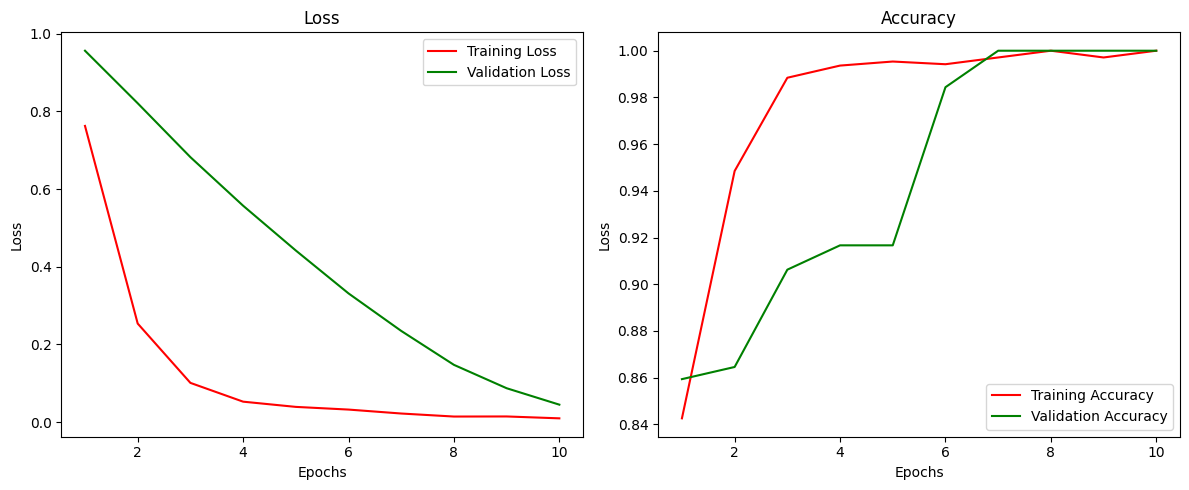

In [15]:
tr_acc= history.history["accuracy"]
tr_loss= history.history["loss"]
val_acc= history.history["val_accuracy"]
val_loss= history.history["val_loss"]

epochs = range(1, len(tr_acc)+1)

# Plot loss
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs,tr_loss, label="Training Loss", color="red")
plt.plot(epochs,val_loss, label="Validation Loss", color="green")
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot accuracy
plt.subplot(1,2,2)
plt.plot(epochs,tr_acc, label="Training Accuracy", color="red")
plt.plot(epochs,val_acc, label="Validation Accuracy", color="green")
plt.title("Accuracy")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()


plt.tight_layout()
plt.show()

## Confusion matrix & Classification report

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step


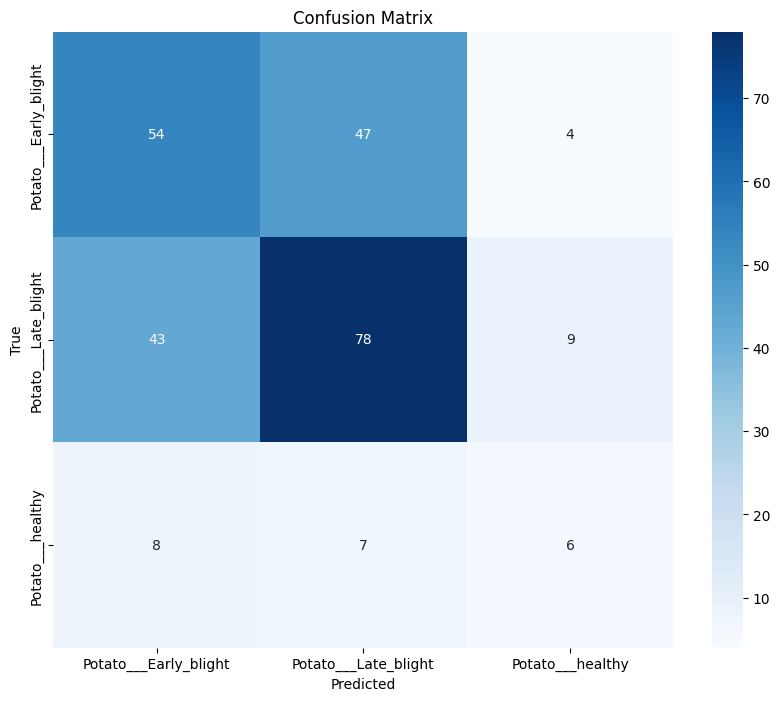

                       precision    recall  f1-score   support

Potato___Early_blight       0.51      0.51      0.51       105
 Potato___Late_blight       0.59      0.60      0.60       130
     Potato___healthy       0.32      0.29      0.30        21

             accuracy                           0.54       256
            macro avg       0.47      0.47      0.47       256
         weighted avg       0.54      0.54      0.54       256



In [16]:
# True labels
true_classes = []
for images, labels in test_ds:
    true_classes.extend(labels.numpy())
true_classes = np.array(true_classes)

# Predictions
pred_probs = model.predict(test_ds)
pred_classes = np.argmax(pred_probs, axis=1)
cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
report = classification_report(true_classes, pred_classes, target_names=class_names)
print(report)

## Model Saving

In [17]:
# Save with backend-friendly filename
model.save("plant_diseases.h5")


### Visualizing Classification Report Metrics

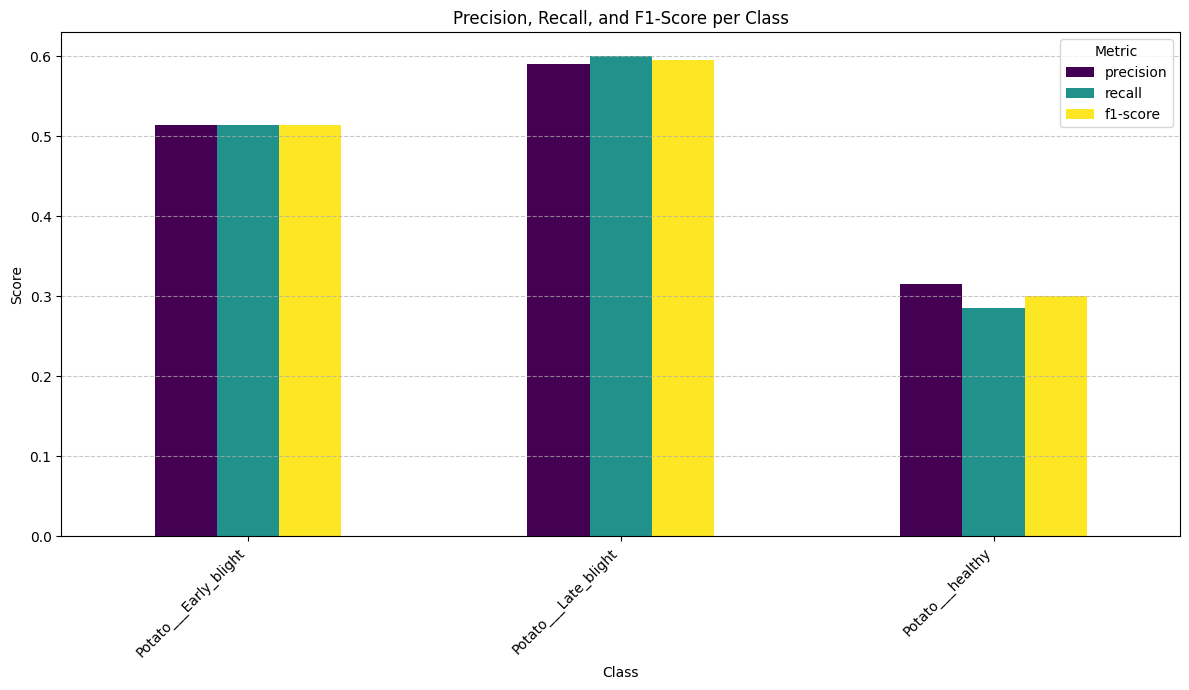

In [18]:
from sklearn.metrics import classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'report' variable from the previous cell is available
# and class_names is also available

# Parse the classification report into a dictionary
report_data = classification_report(true_classes, pred_classes, target_names=class_names, output_dict=True)

# Convert to DataFrame for easier plotting
# Exclude 'accuracy', 'macro avg', 'weighted avg' entries
metrics_df = pd.DataFrame(report_data).transpose()
metrics_df = metrics_df.loc[class_names, ['precision', 'recall', 'f1-score']]

# Plotting
fig, ax = plt.subplots(figsize=(12, 7))
metrics_df.plot(kind='bar', ax=ax, colormap='viridis')

plt.title('Precision, Recall, and F1-Score per Class')
plt.xlabel('Class')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart visually confirms the observations from the text-based classification report. It clearly shows the relative strengths and weaknesses of the model for each class, particularly highlighting the lower performance for the 'Potato___healthy' class across all three metrics (precision, recall, and F1-score). This is a strong visual for any presentation.